# Workflow
1. [Data Import](#data-import)
2. [Modeling](#modeling)
3. [Presentation (Streamlit)]()

# Data Import
Original data is in JSON format.
- [ ] Explain why JSON (+)Save objects (-)manually create CSV
- [ ] Use of Numpy
- [ ] 

## Data exported from Lumeria
1. Player Position
2. Events
3. Map information (build placements)

# Widgets notes
## names = 'values'

Yes. names is a fixed parameter of the .observe() method. You can't rename it:

```python
checkbox.observe(toggle_pois, names='value')    # correct
checkbox.observe(toggle_pois, filter='value')   # error — no such parameter
```

So in that line, both names and 'value' are fixed. Only toggle_pois is yours.
It refers to which property names on the widget you want to watch for changes. A widget has many properties:

```python
print(checkbox.keys)
# ['value', 'description', 'disabled', 'indent', 'layout', 'style', ...]
```

**names='value' means "only call my function when the value property changes." You could watch other properties too:**

```python
checkbox.observe(my_func, names='description')   # fires when label text changes
checkbox.observe(my_func, names='disabled')       # fires when enabled/disabled changes
checkbox.observe(my_func, names=['value', 'disabled'])  # watch multiple
checkbox.observe(my_func)                         # no filter — fires on ANY property change
````

It's called names (plural) because you can pass a list. In practice, you almost always want just 'value' — which is why it looks like boilerplate, but it prevents your function from firing on irrelevant changes like a layout resize.

# Libray choices

## matplotlib vs plotly

Matplotlib is a drawing library — you get a static image (PNG/SVG) and full pixel-level control. The widget backend you've been using adds interactivity, but as you've seen, it's bolted on: you need ipywidgets for sliders, manual draw_idle() calls, FuncAnimation for export. You're managing every redraw yourself.

Plotly is an interactive-first library — every chart is an HTML/JavaScript widget by default. Zoom, pan, hover tooltips, and click events work out of the box with zero extra code. It renders in the browser, not as an image.

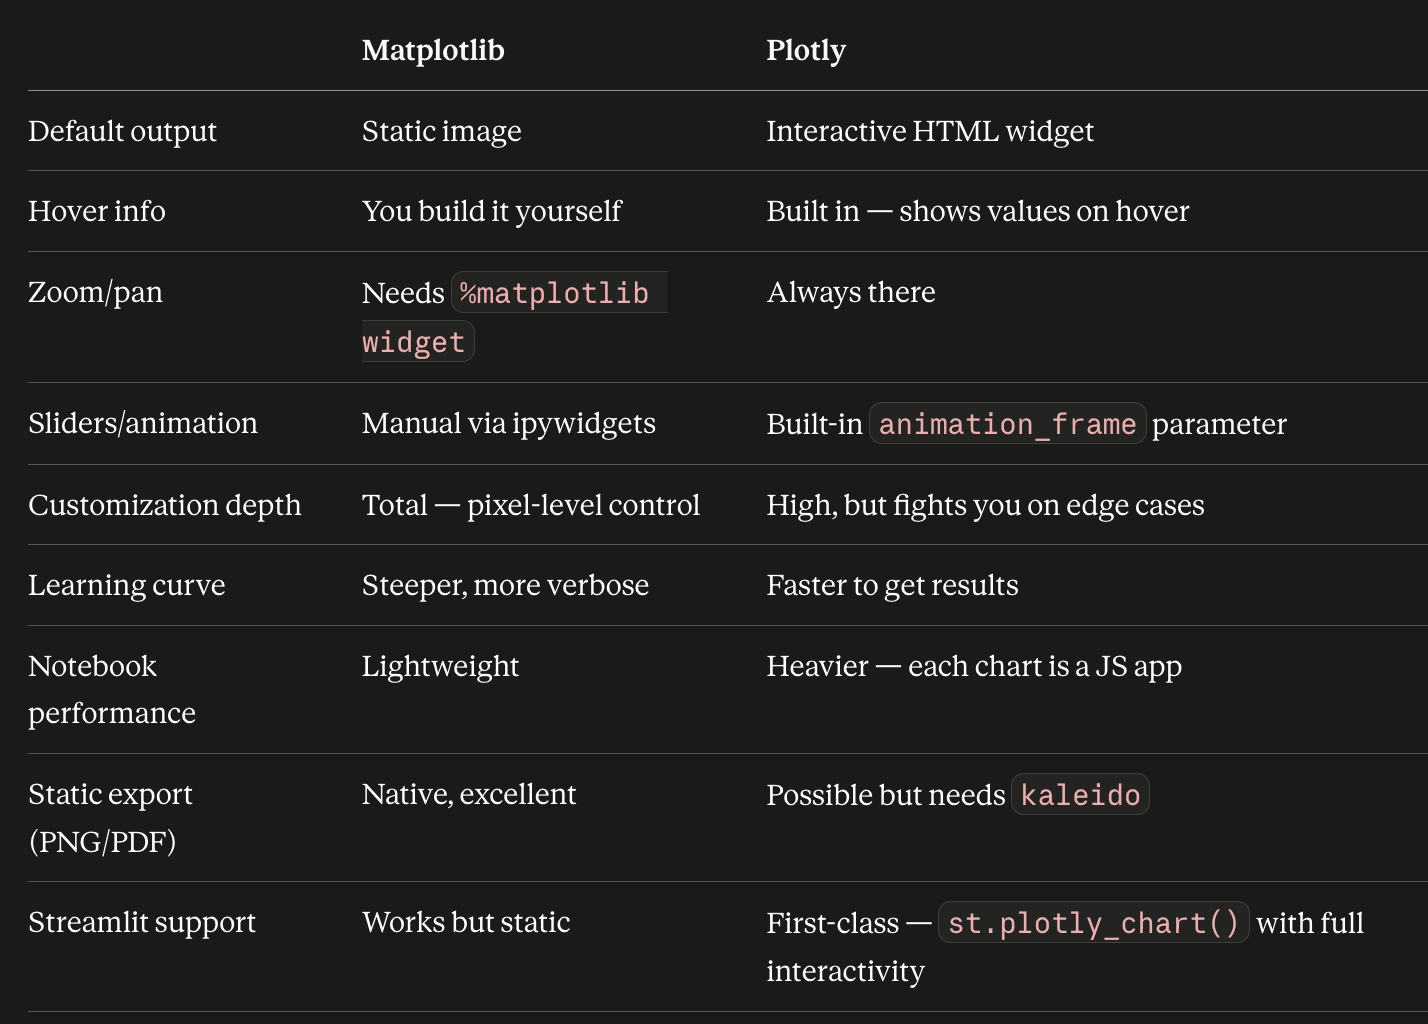

### plotly vs plotly express
Same library, two interfaces:

Plotly Express (px) is the high-level shortcut. One function call, pass a DataFrame directly:

```python
import plotly.express as px

fig = px.scatter(df, x="position_x", y="position_z", color="time",
                 animation_frame="frame", hover_data=["rotation_y"])
fig.show()
```

That single call gives you the scatter, the color scale, hover tooltips, and a time slider with play button — everything you built manually with matplotlib and ipywidgets.

Plotly Graph Objects (go) is the low-level layer underneath. More verbose, full control:

```python
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_list, y=z_list, mode='markers',
                          marker=dict(color=t_list, colorscale='Plasma', size=8)))
fig.update_layout(width=800, height=600, xaxis_title="X", yaxis_title="Z")
fig.show()
```

The relationship is like this: px.scatter(...) generates go.Figure objects behind the scenes. You can start with Express, then drop into Graph Objects when you need finer control — they mix freely:

Because your chart has too many custom layers for Express to handle cleanly. Express works best when you have one DataFrame driving one type of plot:

```python
# Express shines here — one dataset, one scatter, done
fig = px.scatter(df, x="pos_x", y="pos_z", color="time", animation_frame="frame")
````

Your chart stacks five different things:

A background map image
A static trail
Buildings with labels (different data source)
An animated path that grows
A rotating triangle polygon

Express has no way to combine those. It would give you the animated scatter, but you'd immediately need to drop into Graph Objects to add the buildings, the triangle, and the background image. At that point you're writing Graph Objects code anyway — starting there is cleaner than starting with Express and escaping out of it.

Rule of thumb: Express for quick single-dataset charts, Graph Objects when you're compositing multiple layers or need custom animation logic.
